# ROI classification labeling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from masknmf.visualization import ClassificationVis

file_list = [
    r"X:\data\eunji\masknmf-defaults\zplane01\demixing_results.hdf5",
]

To silence this warning, use a fully namespaced name.


In [2]:
vis = ClassificationVis.from_masknmf(file_list, label_names=["soma", "dendrite", "junk"])
vis

In [3]:
# optional: start from 0 labels (same as the red "unlabel all" button)
vis.label(range(len(vis.class_labels)), -1)

In [4]:
labels = vis.class_labels          # (num_rois,) int64, -1 = unlabeled
names = vis.label_names

print(f"{(labels >= 0).sum()}/{len(labels)} labeled")
for i, name in enumerate(names):
    print(f"  {name}: {(labels == i).sum()}")
print(f"  unlabeled: {(labels == -1).sum()}")

0/505 labeled
  soma: 0
  dendrite: 0
  junk: 0
  unlabeled: 505


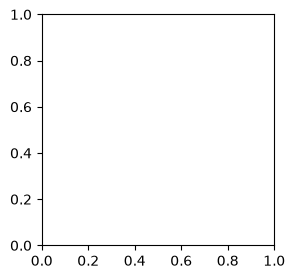

In [5]:
# mean ROI mask per class
classes = [i for i in range(len(names)) if (labels == i).any()]
fig, axes = plt.subplots(1, max(len(classes), 1), figsize=(3 * max(len(classes), 1), 3))
for ax, i in zip(np.atleast_1d(axes), classes):
    ax.imshow(vis.roi_images[labels == i].mean(axis=0), cmap="gray")
    ax.set_title(f"{names[i]} (n={(labels == i).sum()})")
    ax.axis("off")
plt.show()